In [1]:
import os, json, math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

PERSONA_DIR = "outputs_personas_v3"
OUT_DIR = "outputs_networks_v1"
os.makedirs(OUT_DIR, exist_ok=True)

AGENTS_FILE = "agents_threshold_18_realistic.json"

CFG = {
    "n_agents_cap": 2000,

    "alpha_activity": 0.8,
    "beta_homophily": 1.2,

    "k_out": 18,
    "undirected": True,

    "rewire_swaps_per_edge": 3,

    "influence_gamma": 0.7,

    "layout_seed": RANDOM_SEED
}

In [2]:
agents_path = os.path.join(PERSONA_DIR, AGENTS_FILE)
with open(agents_path) as f:
    agents = json.load(f)

agents = agents[: min(len(agents), CFG["n_agents_cap"])]

rows = []
for a in agents:
    aid = a.get("agent_id")
    st = a.get("state", {})
    beh = a.get("behavior", {})
    b = st.get("belief_vector", [np.nan, np.nan])
    rows.append({
        "agent_id": aid,
        "belief0": float(b[0]) if len(b) > 0 else np.nan,
        "belief1": float(b[1]) if len(b) > 1 else np.nan,
        "cluster": st.get("cluster", np.nan),
        "comments_per_day": float(beh.get("comments_per_day", np.nan)),
        "avg_length": float(beh.get("avg_comment_length", np.nan)),
        "sentiment_mean": float(beh.get("sentiment_mean", np.nan))
    })

df = pd.DataFrame(rows).dropna(subset=["agent_id"])
df["comments_per_day"] = pd.to_numeric(df["comments_per_day"], errors="coerce").fillna(0.0)
df["belief0"] = pd.to_numeric(df["belief0"], errors="coerce").fillna(0.0)
df["belief1"] = pd.to_numeric(df["belief1"], errors="coerce").fillna(0.0)
df["avg_length"] = pd.to_numeric(df["avg_length"], errors="coerce").fillna(0.0)

df.shape


(2000, 7)

In [15]:
X = df[["belief0", "belief1"]].to_numpy(dtype=float)

a = df["comments_per_day"].to_numpy(dtype=float)
a = np.clip(a, 0.0, None)
a_norm = a / (np.max(a) + 1e-12)

def activity_weight(ai, aj, alpha):
    return ((ai + 1e-6) * (aj + 1e-6)) ** alpha

def rbf_homophily(dist2, beta):
    return np.exp(-beta * dist2)

def influence_score(i):
    return math.log1p(df.iloc[i]["comments_per_day"]) * math.log1p(df.iloc[i]["avg_length"] + 1.0)

infl = np.array([influence_score(i) for i in range(len(df))], dtype=float)
infl = (infl - infl.min()) / (infl.max() - infl.min() + 1e-12)

In [16]:
def build_activity_homophily_graph(df, X, a, alpha, beta, k_out, undirected=True):
    n = len(df)
    ids = df["agent_id"].tolist()

    D2 = (
        (X[:, None, 0] - X[None, :, 0]) ** 2 +
        (X[:, None, 1] - X[None, :, 1]) ** 2
    )
    np.fill_diagonal(D2, np.inf)

    G = nx.DiGraph()
    for i, u in enumerate(ids):
        nn = np.argpartition(D2[i], k_out)[:k_out]
        for j in nn:
            v = ids[j]
            dist2 = float(D2[i, j])
            w = activity_weight(a[i], a[j], alpha) * rbf_homophily(dist2, beta)
            if w <= 0:
                continue
            G.add_edge(u, v, weight=float(w), dist2=dist2)

    if undirected:
        Gu = nx.Graph()
        for u, v, d in G.edges(data=True):
            w = float(d["weight"])
            if Gu.has_edge(u, v):
                Gu[u][v]["weight"] += w
            else:
                Gu.add_edge(u, v, weight=w)
        return Gu

    return G

G_ah = build_activity_homophily_graph(
    df=df,
    X=X,
    a=a,
    alpha=CFG["alpha_activity"],
    beta=CFG["beta_homophily"],
    k_out=CFG["k_out"],
    undirected=CFG["undirected"]
)

G_ah.number_of_nodes(), G_ah.number_of_edges()

(2000, 21117)

In [17]:
def degree_preserving_rewire(G, swaps_per_edge=3, seed=7):
    H = G.copy()
    m = H.number_of_edges()
    nswap = int(swaps_per_edge * m)

    rng = random.Random(seed)
    try:
        nx.double_edge_swap(H, nswap=nswap, max_tries=nswap * 20, seed=rng)
    except Exception:
        pass
    return H

G_rand = degree_preserving_rewire(G_ah, swaps_per_edge=CFG["rewire_swaps_per_edge"], seed=RANDOM_SEED)
G_rand.number_of_nodes(), G_rand.number_of_edges()

(2000, 21117)

In [18]:
def build_influence_graph(df, X, a, infl, alpha, beta, gamma, k_out, mix=0.6, undirected=True):
    n = len(df)
    ids = df["agent_id"].tolist()

    D2 = (
        (X[:, None, 0] - X[None, :, 0]) ** 2 +
        (X[:, None, 1] - X[None, :, 1]) ** 2
    )
    np.fill_diagonal(D2, np.inf)

    infl_w = (infl + 1e-9) ** gamma
    infl_w = infl_w / (infl_w.sum() + 1e-12)

    G = nx.DiGraph()
    rng = np.random.default_rng(RANDOM_SEED)

    for i, u in enumerate(ids):
        k_sim = int(round(mix * k_out))
        k_inf = max(0, k_out - k_sim)

        nn_sim = np.argpartition(D2[i], k_sim)[:k_sim] if k_sim > 0 else np.array([], dtype=int)

        nn_inf = np.array([], dtype=int)
        if k_inf > 0:
            p = infl_w.copy()
            p[i] = 0.0
            p = p / (p.sum() + 1e-12)
            nn_inf = rng.choice(np.arange(n), size=k_inf, replace=False, p=p)

        nn = np.unique(np.concatenate([nn_sim, nn_inf]))

        for j in nn:
            v = ids[j]
            dist2 = float(D2[i, j])
            base = activity_weight(a[i], a[j], alpha) * rbf_homophily(dist2, beta)
            bias = (infl[j] + 1e-6) ** gamma
            w = base * (0.5 + 0.5 * bias)
            if w <= 0:
                continue
            G.add_edge(u, v, weight=float(w), dist2=dist2)

    if undirected:
        Gu = nx.Graph()
        for u, v, d in G.edges(data=True):
            w = float(d["weight"])
            if Gu.has_edge(u, v):
                Gu[u][v]["weight"] += w
            else:
                Gu.add_edge(u, v, weight=w)
        return Gu

    return G

G_inf = build_influence_graph(
    df=df,
    X=X,
    a=a,
    infl=infl,
    alpha=CFG["alpha_activity"],
    beta=CFG["beta_homophily"],
    gamma=CFG["influence_gamma"],
    k_out=CFG["k_out"],
    mix=0.6,
    undirected=CFG["undirected"]
)

G_inf.number_of_nodes(), G_inf.number_of_edges()

(2000, 26904)

In [19]:
def save_graph(G, name):
    edges = []
    for u, v, d in G.edges(data=True):
        edges.append((u, v, float(d.get("weight", 1.0))))
    edf = pd.DataFrame(edges, columns=["src", "dst", "weight"])
    path = os.path.join(OUT_DIR, f"edges_{name}.parquet")
    edf.to_parquet(path, index=False)

    meta = {
        "name": name,
        "n_nodes": int(G.number_of_nodes()),
        "n_edges": int(G.number_of_edges()),
        "is_directed": bool(G.is_directed()),
        "config": CFG,
        "agents_file": AGENTS_FILE
    }
    with open(os.path.join(OUT_DIR, f"meta_{name}.json"), "w") as f:
        json.dump(meta, f, indent=2)

    return path

p_ah = save_graph(G_ah, "activity_homophily")
p_rd = save_graph(G_rand, "degree_randomized")
p_if = save_graph(G_inf, "influence_biased")

p_ah, p_rd, p_if

('outputs_networks_v1/edges_activity_homophily.parquet',
 'outputs_networks_v1/edges_degree_randomized.parquet',
 'outputs_networks_v1/edges_influence_biased.parquet')

In [20]:
def graph_stats(G):
    deg = np.array([d for _, d in G.degree()], dtype=float)
    wdeg = np.array([d for _, d in G.degree(weight="weight")], dtype=float)

    out = {
        "n_nodes": int(G.number_of_nodes()),
        "n_edges": int(G.number_of_edges()),
        "avg_deg": float(deg.mean()) if len(deg) else 0.0,
        "p90_deg": float(np.quantile(deg, 0.9)) if len(deg) else 0.0,
        "avg_wdeg": float(wdeg.mean()) if len(wdeg) else 0.0,
        "density": float(nx.density(G)) if G.number_of_nodes() > 0 else 0.0,
    }

    try:
        out["avg_clustering"] = float(nx.average_clustering(G))
    except Exception:
        out["avg_clustering"] = np.nan

    return out

stats = pd.DataFrame([
    {"graph": "activity_homophily", **graph_stats(G_ah)},
    {"graph": "degree_randomized", **graph_stats(G_rand)},
    {"graph": "influence_biased", **graph_stats(G_inf)},
])

stats

,graph,n_nodes,n_edges,avg_deg,p90_deg,avg_wdeg,density,avg_clustering
0,activity_homophily,2000,21117,21.117,24.0,51.736741,0.010564,0.597702
1,degree_randomized,2000,21117,21.117,24.0,21.072049,0.010564,0.009505
2,influence_biased,2000,26904,26.904,33.0,32.033228,0.013459,0.165542


In [21]:
id_to_row = {r.agent_id: r for r in df.itertuples(index=False)}

def node_activity(u):
    return float(id_to_row[u].comments_per_day)

def node_rigidity(u):
    return float(id_to_row[u].belief0)

def normalize(vals):
    vals = np.array(vals, dtype=float)
    lo, hi = np.quantile(vals, 0.02), np.quantile(vals, 0.98)
    vals = np.clip(vals, lo, hi)
    vals = (vals - vals.min()) / (vals.max() - vals.min() + 1e-12)
    return vals

def plot_graph(G, title, max_nodes=900, seed=7):
    nodes = list(G.nodes())
    if len(nodes) > max_nodes:
        nodes = random.Random(seed).sample(nodes, max_nodes)
        H = G.subgraph(nodes).copy()
    else:
        H = G

    pos = nx.spring_layout(H, seed=seed, k=None)

    act = np.array([node_activity(u) for u in H.nodes()], dtype=float)
    rig = np.array([node_rigidity(u) for u in H.nodes()], dtype=float)

    act_n = normalize(act)
    rig_n = normalize(rig)

    sizes = 25 + 80 * (rig_n ** 1.2)

    plt.figure(figsize=(11, 8))
    nx.draw_networkx_edges(H, pos, alpha=0.08, width=0.7)

    sc = plt.scatter(
        [pos[u][0] for u in H.nodes()],
        [pos[u][1] for u in H.nodes()],
        c=act_n,
        s=sizes,
        alpha=0.9
    )

    plt.title(title)
    plt.axis("off")
    cb = plt.colorbar(sc, shrink=0.85)
    cb.set_label("activity (normalized log-scale proxy)")

    plt.tight_layout()
    plt.show()

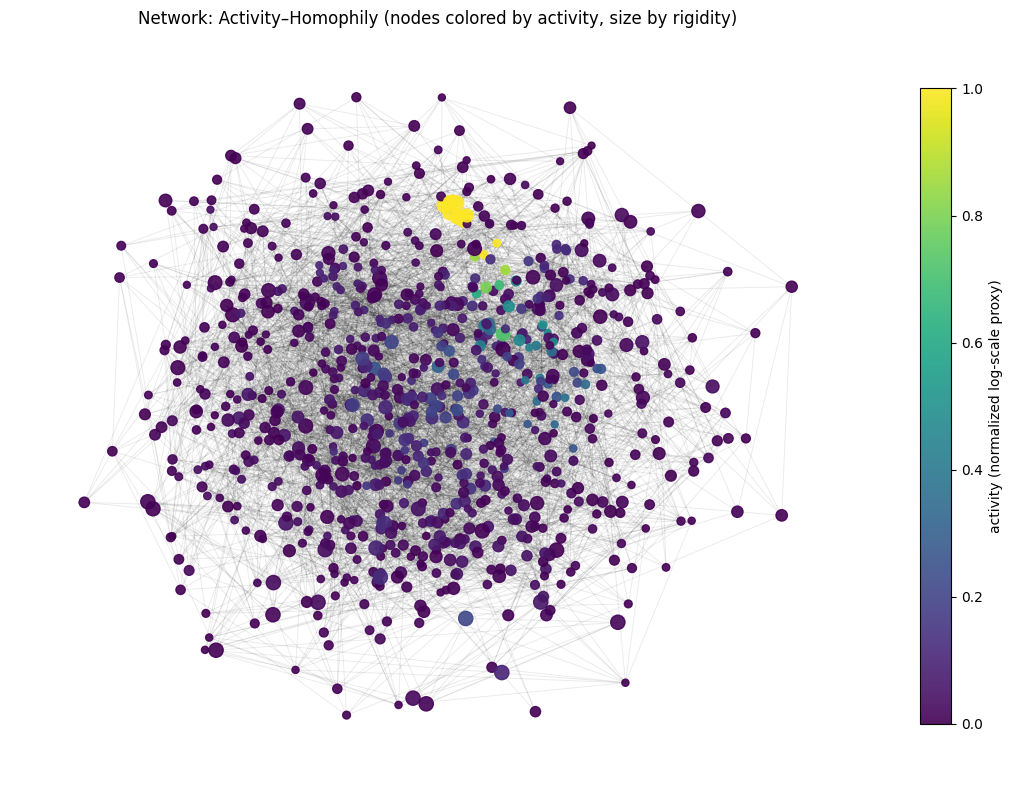

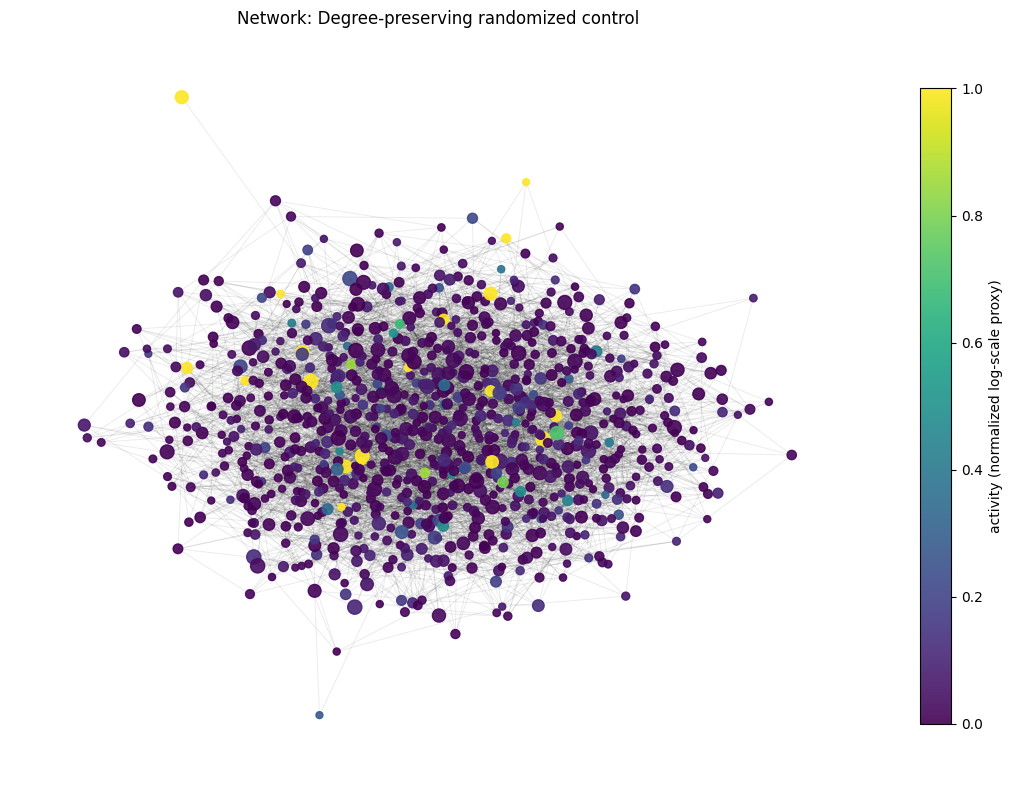

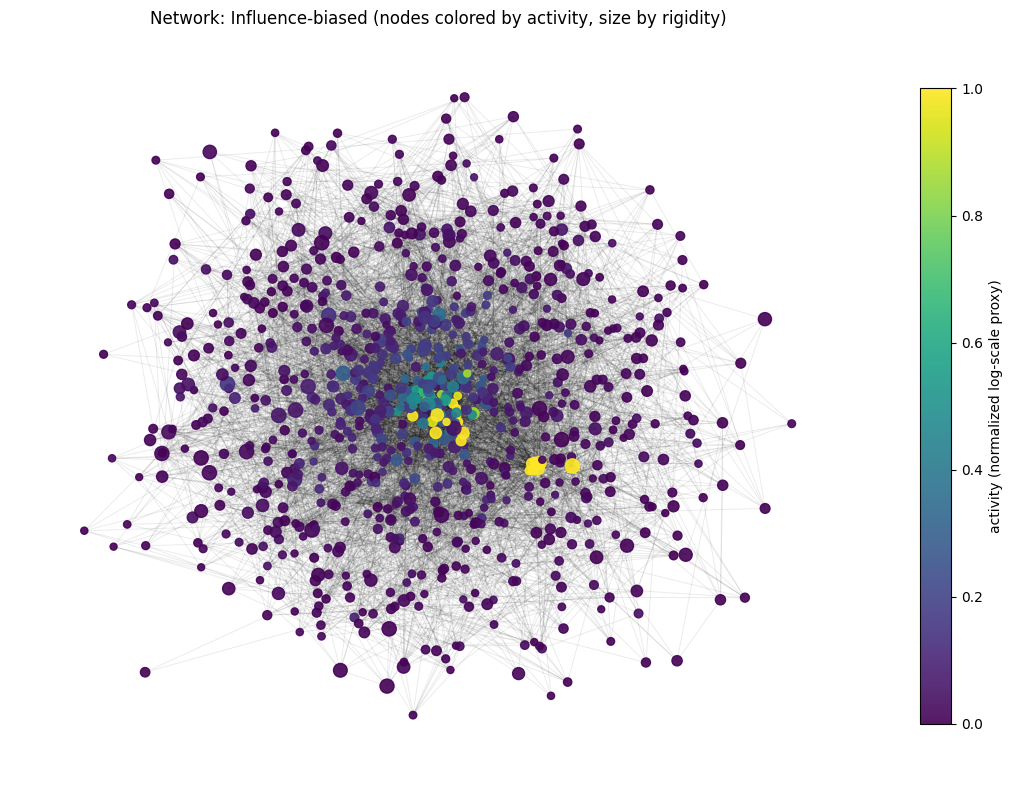

In [22]:
plot_graph(G_ah, "Network: Activity–Homophily (nodes colored by activity, size by rigidity)", max_nodes=900, seed=CFG["layout_seed"])
plot_graph(G_rand, "Network: Degree-preserving randomized control", max_nodes=900, seed=CFG["layout_seed"])
plot_graph(G_inf, "Network: Influence-biased (nodes colored by activity, size by rigidity)", max_nodes=900, seed=CFG["layout_seed"])

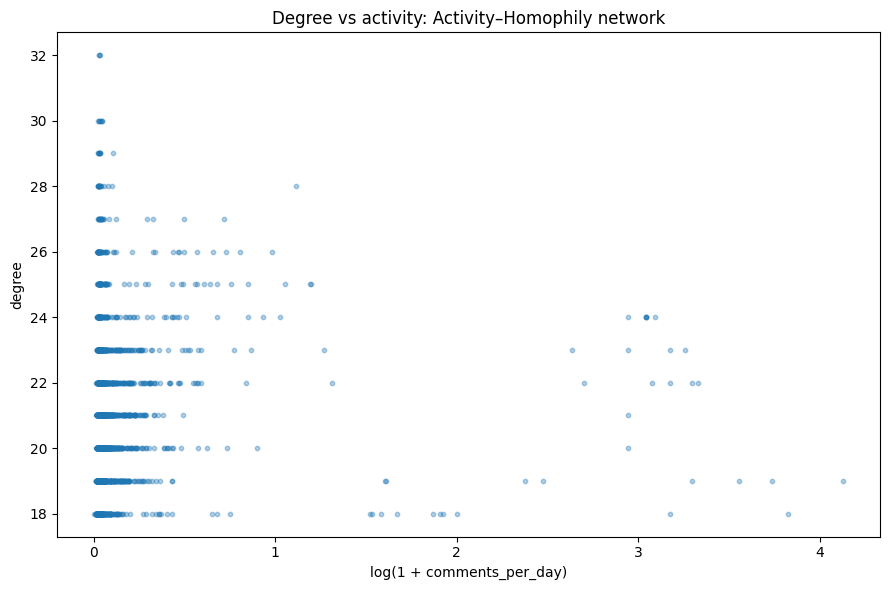

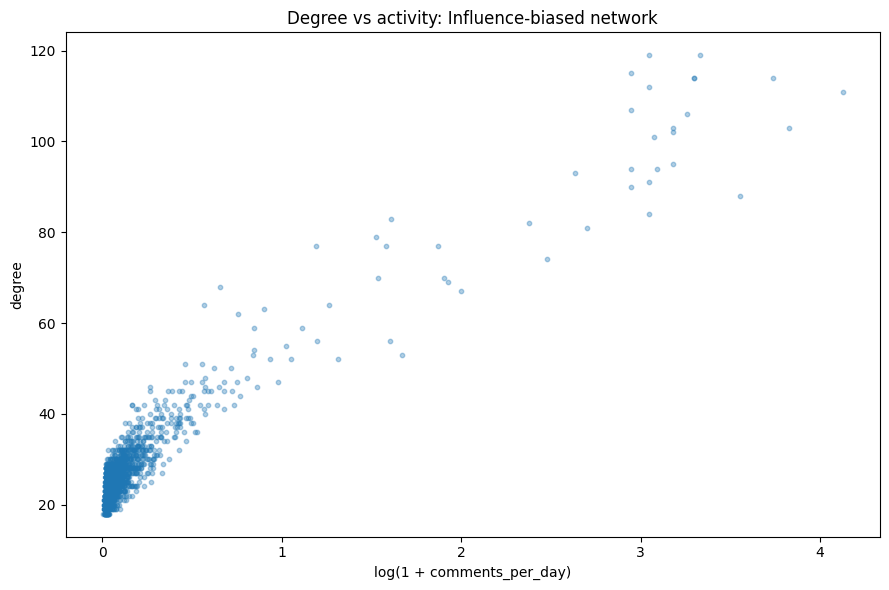

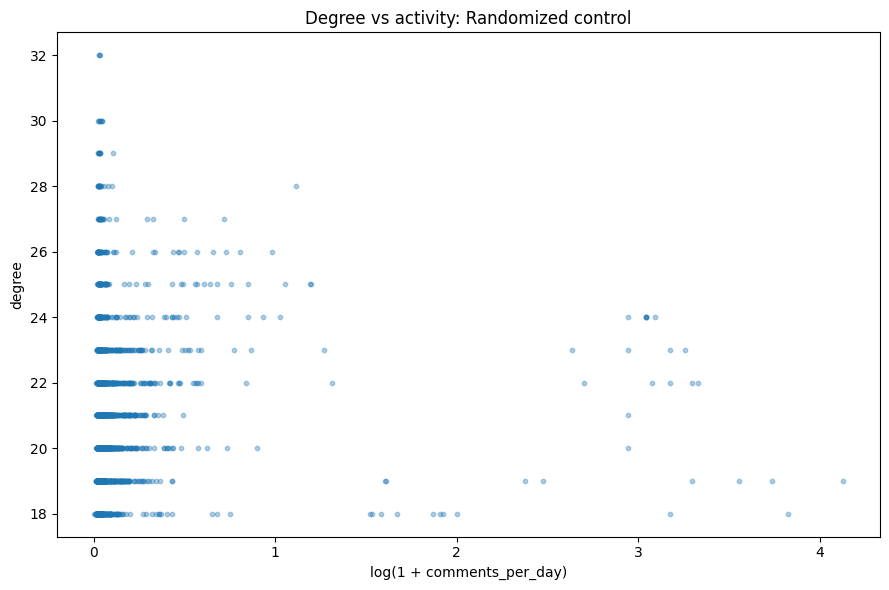

In [26]:
def deg_activity_scatter(G, title):
    xs = []
    ys = []
    for u in G.nodes():
        xs.append(node_activity(u))
        ys.append(G.degree(u))
    xs = np.array(xs, dtype=float)
    ys = np.array(ys, dtype=float)

    x = np.log1p(xs)

    plt.figure(figsize=(9, 6))
    plt.scatter(x, ys, s=10, alpha=0.35)
    plt.title(title)
    plt.xlabel("log(1 + comments_per_day)")
    plt.ylabel("degree")
    plt.tight_layout()
    plt.show()

deg_activity_scatter(G_ah, "Degree vs activity: Activity–Homophily network")
deg_activity_scatter(G_inf, "Degree vs activity: Influence-biased network")
deg_activity_scatter(G_rand, "Degree vs activity: Randomized control")

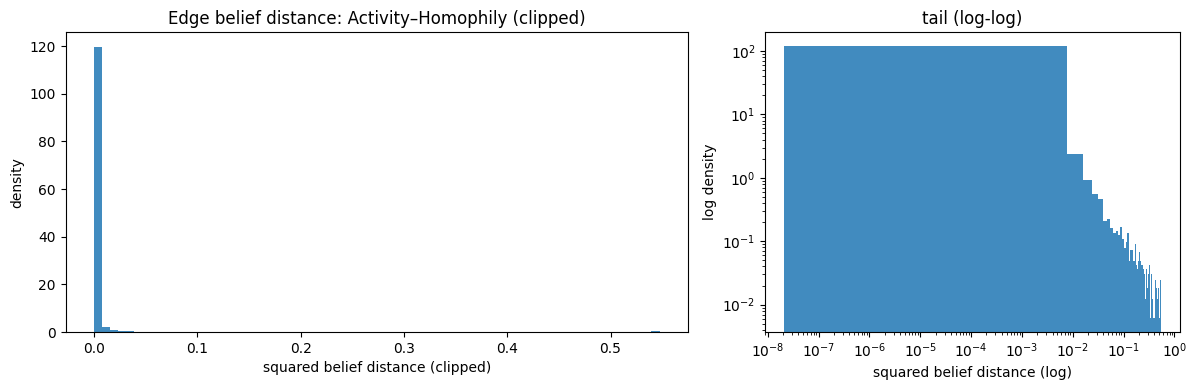

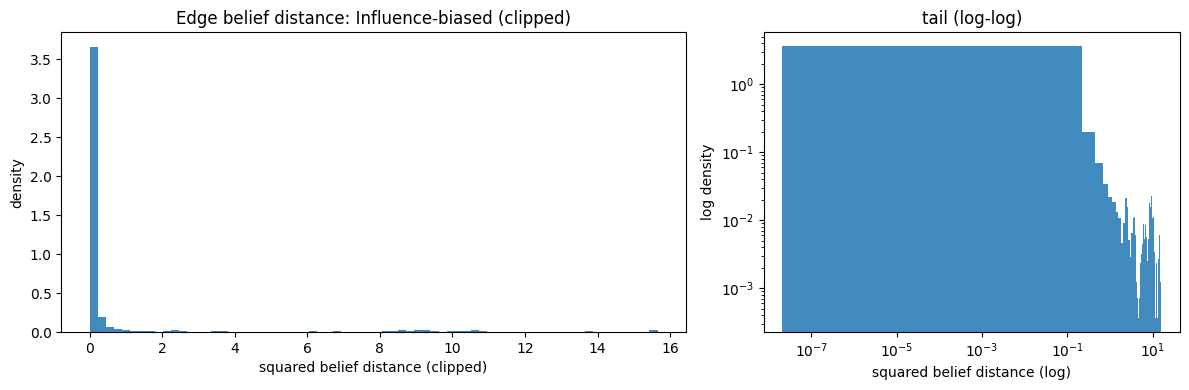

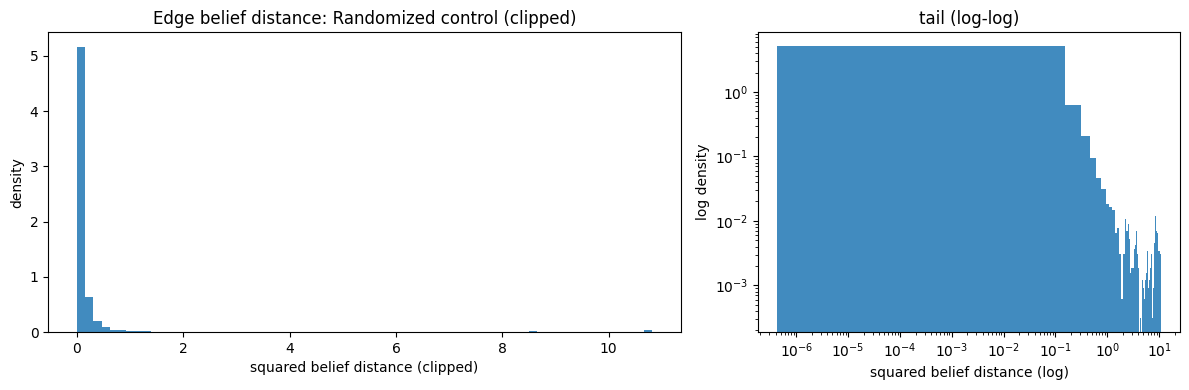

In [28]:
import numpy as np
import matplotlib.pyplot as plt

def edge_dist2(G, X_map, n_sample=25000, seed=7):
    edges = list(G.edges())
    if len(edges) == 0:
        return np.array([])
    if len(edges) > n_sample:
        edges = random.Random(seed).sample(edges, n_sample)

    ds = []
    for u, v in edges:
        du = X_map[u]
        dv = X_map[v]
        ds.append(float(((du - dv) ** 2).sum()))
    return np.array(ds, dtype=float)

def plot_edge_dist_adaptive(ds, title, clip_q=(0.0, 0.995), bins=60):
    ds = ds[np.isfinite(ds)]
    if len(ds) == 0:
        return

    lo = np.quantile(ds, clip_q[0])
    hi = np.quantile(ds, clip_q[1])
    if hi <= lo:
        hi = float(ds.max())

    ds_clip = np.clip(ds, lo, hi)

    fig, ax = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [3, 2]})

    ax[0].hist(ds_clip, bins=bins, density=True, alpha=0.85)
    ax[0].set_title(title + " (clipped)")
    ax[0].set_xlabel("squared belief distance (clipped)")
    ax[0].set_ylabel("density")

    ds_pos = ds_clip[ds_clip > 0]
    if len(ds_pos) > 0:
        ax[1].hist(ds_pos, bins=bins, density=True, alpha=0.85, log=True)
        ax[1].set_xscale("log")
        ax[1].set_title("tail (log-log)")
        ax[1].set_xlabel("squared belief distance (log)")
        ax[1].set_ylabel("log density")

    plt.tight_layout()
    plt.show()

X_map = {df.iloc[i]["agent_id"]: X[i] for i in range(len(df))}

ds_ah = edge_dist2(G_ah, X_map, n_sample=25000, seed=RANDOM_SEED)
ds_inf = edge_dist2(G_inf, X_map, n_sample=25000, seed=RANDOM_SEED)
ds_rand = edge_dist2(G_rand, X_map, n_sample=25000, seed=RANDOM_SEED)

plot_edge_dist_adaptive(ds_ah, "Edge belief distance: Activity–Homophily", clip_q=(0.0, 0.995), bins=70)
plot_edge_dist_adaptive(ds_inf, "Edge belief distance: Influence-biased", clip_q=(0.0, 0.995), bins=70)
plot_edge_dist_adaptive(ds_rand, "Edge belief distance: Randomized control", clip_q=(0.0, 0.995), bins=70)

In [29]:
net_manifest = {
    "agents_file": AGENTS_FILE,
    "out_dir": OUT_DIR,
    "graphs": {
        "activity_homophily": "edges_activity_homophily.parquet",
        "degree_randomized": "edges_degree_randomized.parquet",
        "influence_biased": "edges_influence_biased.parquet"
    },
    "config": CFG
}

with open(os.path.join(OUT_DIR, "networks_manifest.json"), "w") as f:
    json.dump(net_manifest, f, indent=2)

os.path.join(OUT_DIR, "networks_manifest.json")

'outputs_networks_v1/networks_manifest.json'